# Recurrent Group-Structured World Model: Demo

True state: `(orientation, has_key, door_open)`.

Actions: `turn_left`, `turn_right` (movement -- generate Z4, each other's inverse),
`pick_up`, `open_door` (interaction -- non-invertible; `open_door` only works if `has_key`).

The observation given to the encoder is **partial**: at each step it is only
`(orientation, last_action)` -- `has_key`/`door_open` are never observed
directly. The GRU has to track them from the action history alone; they're
only supervised at the decoder output.

This notebook loads a checkpoint trained with `python train.py` and inspects
what it learned. Run `python train.py` first if `../checkpoint.pt` doesn't
exist yet.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.environment import ACTION_NAMES, N_ACTIONS, N_GROUP_ACTIONS, OBS_DIM, STATE_DIM, sample_trajectories
from src.model import WorldModel

ckpt = torch.load("../checkpoint.pt", map_location="cpu")
model = WorldModel(obs_dim=OBS_DIM, state_dim=STATE_DIM, latent_dim=ckpt["latent_dim"],
                    n_actions=N_ACTIONS, n_group_actions=N_GROUP_ACTIONS)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Loaded model with latent_dim =", ckpt["latent_dim"])

Loaded model with latent_dim = 8


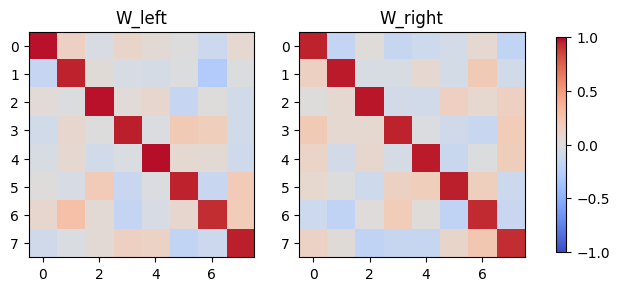

In [2]:
# The learned rotation operators W_left, W_right (movement actions only --
# pick_up/open_door never have one; they always use the interaction MLP).
with torch.no_grad():
    W = model.transition.W()

left, right = ACTION_NAMES.index("turn_left"), ACTION_NAMES.index("turn_right")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, name, idx in zip(axes, ["W_left", "W_right"], [left, right]):
    im = ax.imshow(W[idx].numpy(), cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(name)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [3]:
# Algebraic checks: is turn_left close to order 4? Is turn_right its inverse?
# The group/interaction split is fixed by construction (see src/model.py) --
# these numbers only ask whether *training* happened to push the learned
# operators toward the relations turning implies. It isn't guaranteed.
D = W.shape[-1]
I = torch.eye(D)

w4 = torch.linalg.matrix_power(W[left], 4)
print("||W_left^4 - I|| =", (w4 - I).norm().item())

inv_err = (W[right] @ W[left] - I).norm().item()
print("||W_right @ W_left - I|| =", inv_err)

||W_left^4 - I|| = 3.023059844970703
||W_right @ W_left - I|| = 0.4532841145992279


In [4]:
# Teacher-forced rollout: the encoder re-observes the (partial) real
# trajectory at every step -- this is what the model was trained to do.
rng = np.random.default_rng(0)
states, obs_seq, actions = sample_trajectories(batch_size=1, horizon=8, rng=rng)

with torch.no_grad():
    tf_preds = model.teacher_forced(obs_seq, actions)

print(f"{'step':>4} {'action':<10} {'predicted (orient, key, door)':<32} {'true'}")
for t in range(actions.shape[1]):
    a_name = ACTION_NAMES[actions[0, t].item()]
    pred = tf_preds[t][0].round().tolist()
    true = states[0, t + 1].tolist()
    print(f"{t:>4} {a_name:<10} {str(pred):<32} {true}")

step action     predicted (orient, key, door)    true
   0 pick_up    [-0.0, 0.0, 0.0, 1.0, 1.0, 0.0]  [0.0, 0.0, 0.0, 1.0, 1.0, 0.0]
   1 pick_up    [-0.0, -0.0, 0.0, 1.0, 1.0, -0.0] [0.0, 0.0, 0.0, 1.0, 1.0, 0.0]
   2 turn_right [1.0, -0.0, 0.0, 0.0, 1.0, 0.0]  [1.0, 0.0, 0.0, 0.0, 1.0, 0.0]
   3 turn_right [-0.0, 1.0, -0.0, 0.0, 1.0, 0.0] [0.0, 1.0, 0.0, 0.0, 1.0, 0.0]
   4 turn_left  [1.0, 0.0, 0.0, -0.0, 1.0, -0.0] [1.0, 0.0, 0.0, 0.0, 1.0, 0.0]
   5 turn_left  [-0.0, 0.0, 0.0, 1.0, 1.0, -0.0] [0.0, 0.0, 0.0, 1.0, 1.0, 0.0]
   6 turn_left  [-0.0, 0.0, 1.0, 0.0, 1.0, -0.0] [0.0, 0.0, 1.0, 0.0, 1.0, 0.0]
   7 turn_left  [-0.0, 1.0, 0.0, -0.0, 1.0, 0.0] [0.0, 1.0, 0.0, 0.0, 1.0, 0.0]


In [5]:
# Latent rollout: the observation is encoded ONCE (step 0), then every
# later prediction comes purely from composing the transition on z --
# no re-observation. This is a much harder test the model was never
# directly trained for (teacher forcing only ever chains one transition
# call at a time), so don't expect it to match the teacher-forced table
# above -- that gap is itself the point: see the README for why.
with torch.no_grad():
    ro_preds = model.rollout(obs_seq[:, 0], actions)

print(f"{'step':>4} {'action':<10} {'predicted (orient, key, door)':<32} {'true'}")
for t in range(actions.shape[1]):
    a_name = ACTION_NAMES[actions[0, t].item()]
    pred = ro_preds[t][0].round().tolist()
    true = states[0, t + 1].tolist()
    print(f"{t:>4} {a_name:<10} {str(pred):<32} {true}")

step action     predicted (orient, key, door)    true
   0 pick_up    [-0.0, 0.0, 0.0, 1.0, 1.0, 0.0]  [0.0, 0.0, 0.0, 1.0, 1.0, 0.0]
   1 pick_up    [-0.0, -0.0, 1.0, 0.0, 1.0, -0.0] [0.0, 0.0, 0.0, 1.0, 1.0, 0.0]
   2 turn_right [0.0, -0.0, 1.0, 0.0, 1.0, -0.0] [1.0, 0.0, 0.0, 0.0, 1.0, 0.0]
   3 turn_right [0.0, -0.0, 1.0, 0.0, 1.0, -0.0] [0.0, 1.0, 0.0, 0.0, 1.0, 0.0]
   4 turn_left  [0.0, -0.0, 1.0, 0.0, 1.0, -0.0] [1.0, 0.0, 0.0, 0.0, 1.0, 0.0]
   5 turn_left  [0.0, -0.0, 1.0, 0.0, 1.0, -0.0] [0.0, 0.0, 0.0, 1.0, 1.0, 0.0]
   6 turn_left  [0.0, -0.0, 1.0, 0.0, 1.0, -0.0] [0.0, 0.0, 1.0, 0.0, 1.0, 0.0]
   7 turn_left  [0.0, -0.0, 1.0, 0.0, 0.0, -0.0] [0.0, 1.0, 0.0, 0.0, 1.0, 0.0]
